In [65]:

def normalize_style(style):
    s = style
    if s in ["Even 8th's", "Even 8's"]:
        return 'Even 8ths'
    if 'Swing' in s or 'Fusion' in s or 'Jazz' in s:
        return 'Jazz'
    if 'Blues' in s:
        return 'Blues'
    if 'Folk' in s:
        return 'Folk'
    if 'Bossa' in s:
        return 'Bossa'
    if 'Reggae' in s:
        return 'Reggae'
    if 'Samba' in s:
        return 'Samba'
    if 'Funk' in s:
        return 'Funk'
    if 'Pop' in s:
        return 'Pop'
    if 'Son' in s:
        return 'Son'
    if 'Rock' in s or s == 'Beatles':
        return 'Rock'
    if 'Soul' in s:
        return 'Soul'
    if 'Balad' in s:
        return 'Balad'
    if s == "R'n'B":
        return "RnB"
    if s == 'Afoxe':
        return 'Afoxé'
    if s in ['Worship', 'Traditional Gospel']:
        return 'Gospel'
    if s == 'Even 8ths':
        return 'Pop'
    return s

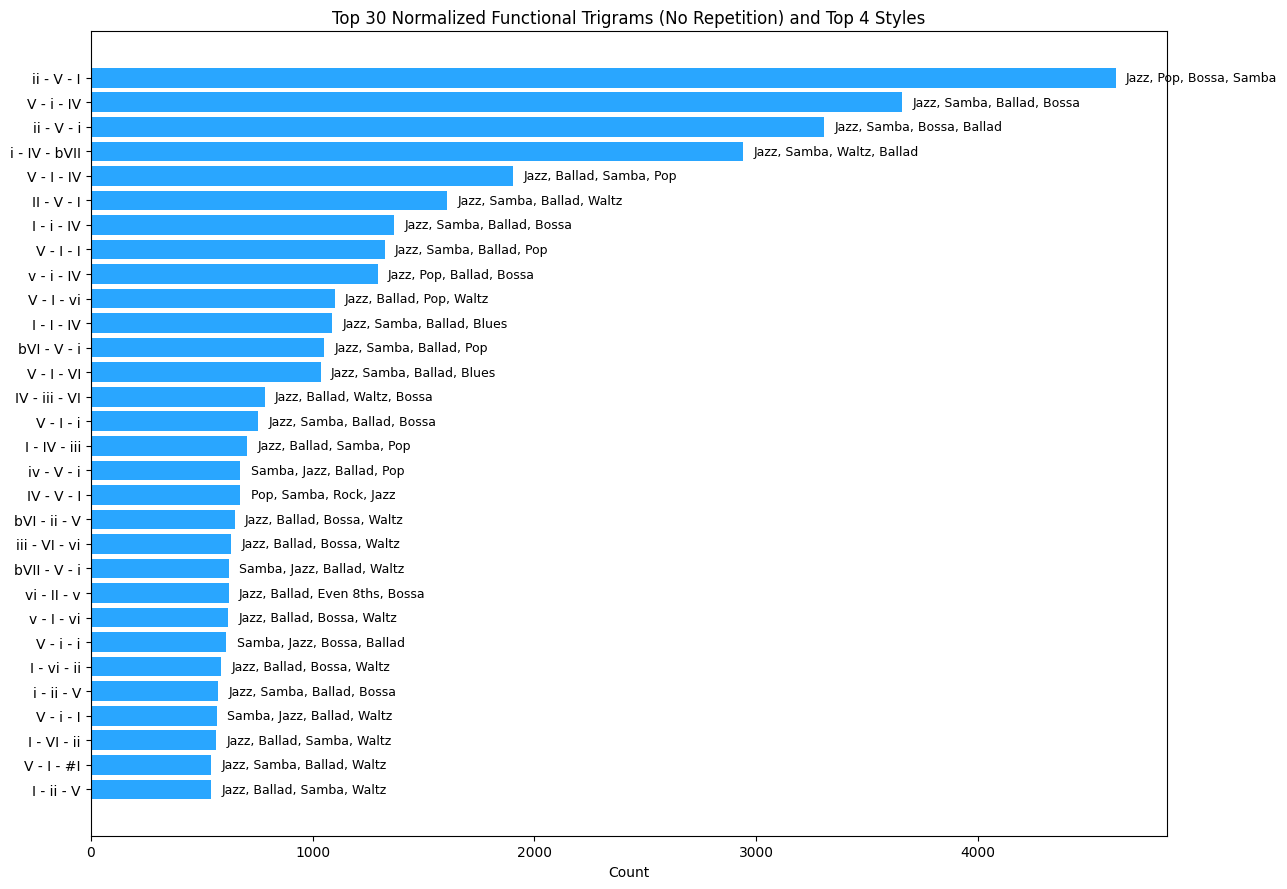

In [66]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def normalize_function_label(label):
    # Remove accidentals, extensions, and alterations: keep only Roman numerals and accidentals at start
    match = re.match(r"([b#♭♯]*[IViv]+)", label)
    return match.group(1) if match else label

def normalize_trigram(function_trigram):
    # Return canonicalized tuple of roman numerals
    return tuple(normalize_function_label(x) for x in function_trigram)

# Load data
with open('/workspace/dataset/trigrams/trigram_dataset.json', 'r') as f:
    data = json.load(f)

# Aggregate: trigram -> count, style counter
trigram_count = Counter()
trigram_styles = defaultdict(Counter)

for entry in data:
    func_trigram = normalize_trigram(entry['function'])
    if len(set(func_trigram)) == 1:
        continue
    count = entry['count']
    for style in entry['styles']:
        norm_style = normalize_style(style)
        trigram_styles[func_trigram][norm_style] += count
    trigram_count[func_trigram] += count

# Select top 
selected = 30
top_trigrams = trigram_count.most_common(selected)

# Prepare for plotting
plot_labels = []
plot_counts = []
plot_topstyles = []

num_styles = 4
for trigram, count in top_trigrams:
    roman_label = ' - '.join(trigram)
    styles_counter = trigram_styles[trigram]
    top_n_styles = [s for s, _ in styles_counter.most_common(num_styles)]
    plot_labels.append(roman_label)
    plot_counts.append(count)
    plot_topstyles.append(', '.join(top_n_styles))

# Reverse for horizontal plot (most common at top)
plot_labels = plot_labels[::-1]
plot_counts = plot_counts[::-1]
plot_topstyles = plot_topstyles[::-1]

# Plot
fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(plot_labels, plot_counts, color="#29a6ff")

for i, (c, styles) in enumerate(zip(plot_counts, plot_topstyles)):
    ax.text(c + max(plot_counts) * 0.01, i, styles, va='center', fontsize=9, color="#000000")

ax.set_xlabel('Count')
ax.set_title(f'Top {selected} Normalized Functional Trigrams (No Repetition) and Top {num_styles} Styles')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1049812/2037479474.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_1049812/2037479474.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


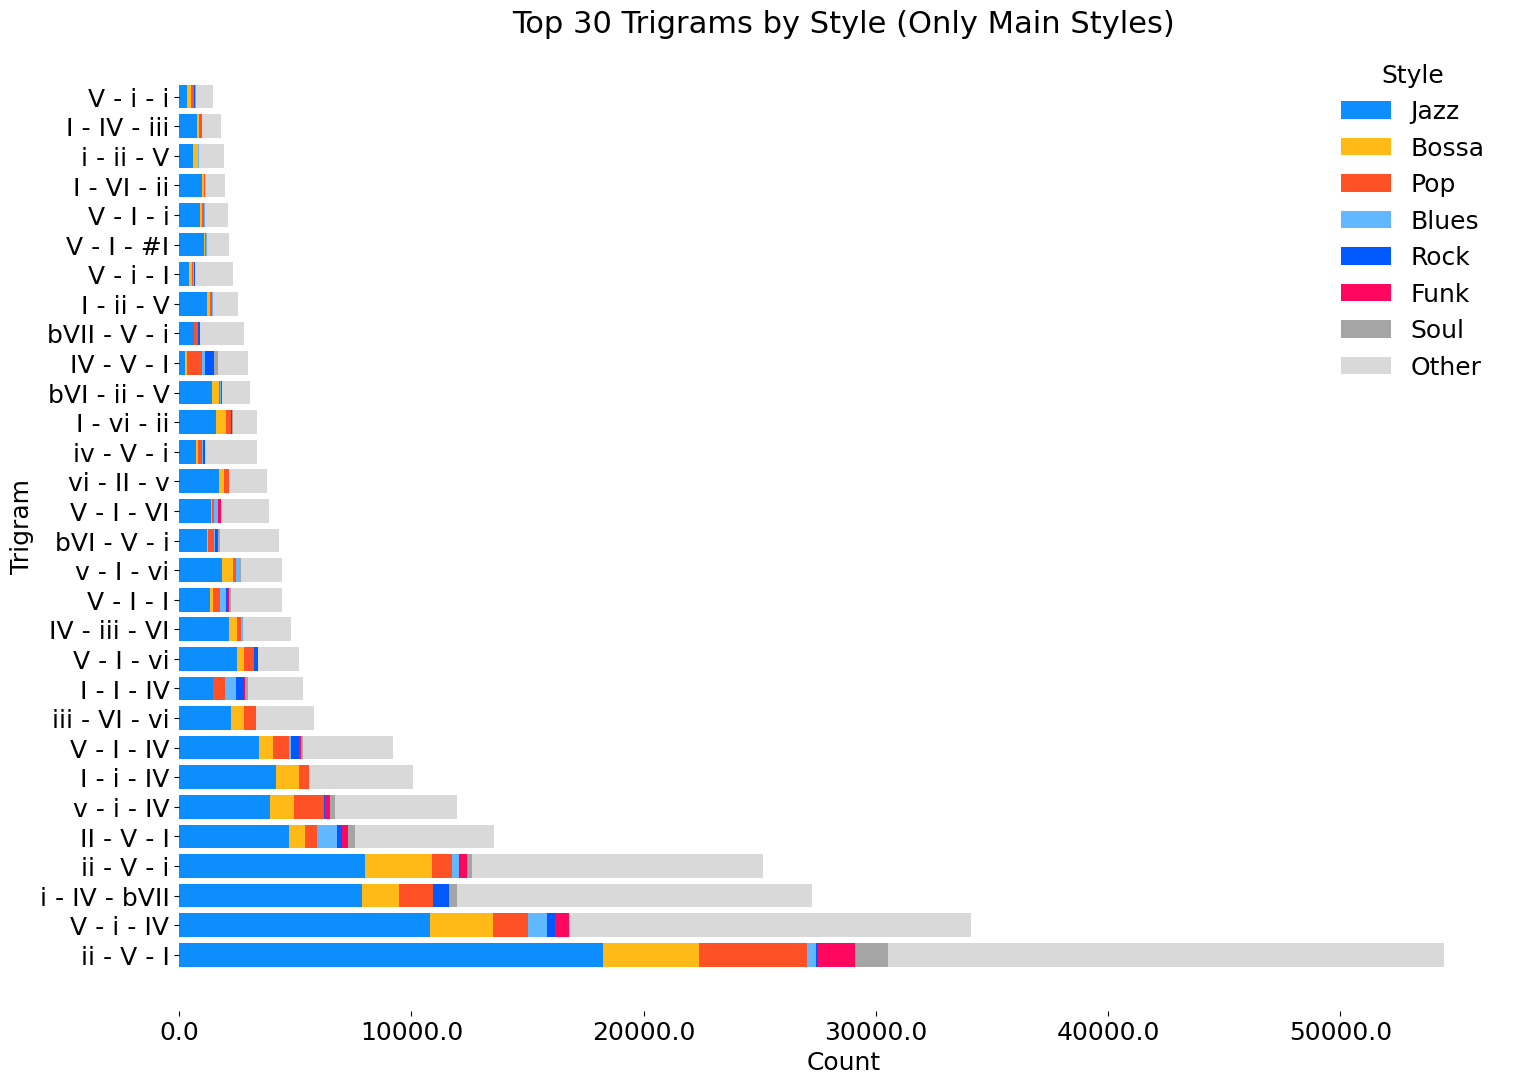

In [93]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
chosen_styles = ['Jazz', 'Bossa', 'Pop', 'Blues', 'Rock', 'Funk', 'Soul']

# Get top N trigrams
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build the data matrix and compute total counts for sorting
data = []
totals = []
for trigram, _ in top_trigrams:
    style_counts = trigram_styles[trigram]
    row = [style_counts.get(style, 0) for style in chosen_styles]
    other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]

# Custom colors for these genres
custom_palette = {
    'Jazz': "#0c8eff",
    'Bossa': "#ffba18",
    'Pop': "#ff5125",
    'Blues': "#61b8ff",
    'Rock': "#0059ff",
    'Funk': "#ff075e",
    'Soul': "#a5a5a5",
    'Other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['Other']]

# Plot
fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['Other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
# Set bigger font sizes
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style (Only Main Styles)', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)

# Legend with bigger font
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()



In [68]:
import re

def split_function_label(label):
    match = re.match(r"^([b#♭♯]*[IViv]+)(.*)$", label)
    if match:
        degree = match.group(1)
        extension = match.group(2)
        return degree, extension
    else:
        return label, ""

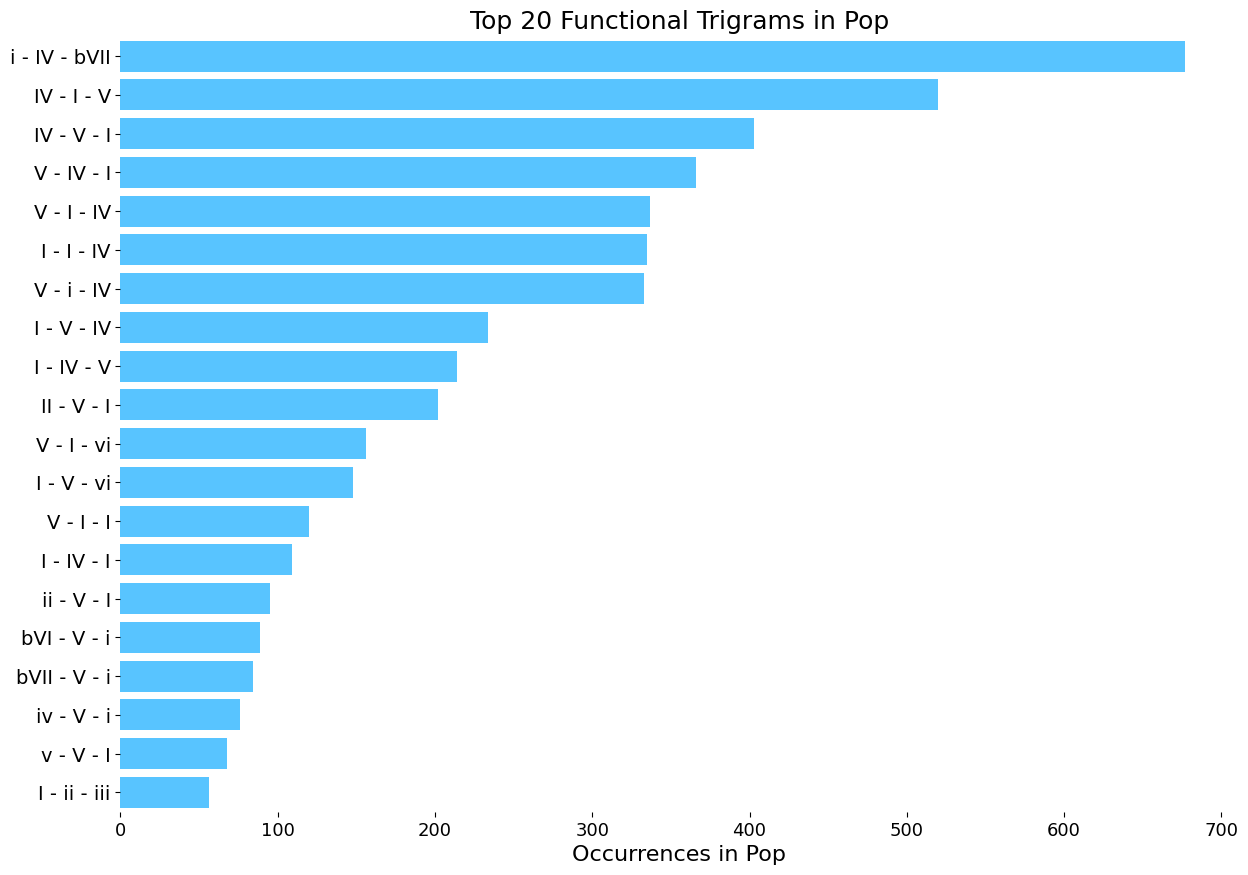

In [69]:
import json
import matplotlib.pyplot as plt

# Load the data
with open('/workspace/dataset/trigrams/functional_trigrams.json', 'r') as f:
    data = json.load(f)

# Extract trigrams with Pop in styles, and get their Pop count
pop_trigrams = []
style = 'Rock'
for entry in data:
    for s, count in entry['styles']:
        if s == style:
            pop_trigrams.append({
                "function": entry['function'],
                "pop_count": count
            })
            break

# Sort by Pop count, descending
pop_trigrams = sorted(pop_trigrams, key=lambda x: x['pop_count'], reverse=True)[:20]

# Prepare data for plotting
labels = [' - '.join(tri['function']) for tri in pop_trigrams]
counts = [tri['pop_count'] for tri in pop_trigrams]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels[::-1], counts[::-1], color="#58c4ff")

# Remove all spines (the box/frame)
for spine in ax.spines.values():
    spine.set_visible(False)

# Tighten layout
plt.tight_layout(pad=0.05)

# Set y-limits to crop empty space
ax.set_ylim(-0.5, len(labels) - 0.5)  # Half-bar padding

ax.set_xlabel('Occurrences in Pop', fontsize=16)
ax.set_title('Top 20 Functional Trigrams in Pop', fontsize=18)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=13)

plt.show()

In [73]:
from trigram_search import query_trigram_usage

result = query_trigram_usage(["ii", "V", "I"])
print(result)


{'functional_trigrams': {'count': 4620, 'styles': [['Jazz', 18241], ['Pop', 4641], ['Bossa', 4151], ['Samba', 4031], ['Ballad', 4030], ['Latin', 3201], ['Waltz', 3197], ['Bolero', 1814], ['Gospel', 1619], ['Funk', 1597]], 'matched': 'exact', 'function': ['ii', 'V', 'I']}, 'trigram_dataset': {'total_count': 10298, 'styles': [('Medium Swing', 8565), ('Ballad', 8160), ('Samba', 6991), ('Medium Up Swing', 6639), ('Up Tempo Swing', 6534), ('Waltz', 6392), ('Bossa Nova', 6231), ('Slow Swing', 5713), ('Latin', 5194), ('Even 8ths', 2645)], 'composers': [('Richard Rodgers', 5151), ('Harold Arlen', 5005), ('Cole Porter', 4630), ('George Gershwin', 4550), ('Duke Ellington', 4444), ('Exercise', 4430), ('Antonio-Carlos Jobim', 4319), ('Jimmy Van-Heusen', 4199), ('Hoagy Carmichael', 3941), ('Frank Loesser', 3886)]}}


{'functional_trigrams': {'count': 674, 'styles': [['Pop', 680], ['Samba', 441], ['Rock', 403], ['Jazz', 270], ['Soul', 150], ['Gospel', 137], ['Folk', 123], ['Ballad', 103], ['Blues', 102], ['Latin', 82]], 'matched': 'exact', 'function': ['IV', 'V', 'I']}, 'trigram_dataset': {'total_count': 1817, 'styles': [('Samba', 924), ('Medium Swing', 642), ('Ballad', 462), ('Samba Enredo', 407), ('Rock Pop', 395), ('Rock', 357), ('Pop', 308), ('Up Tempo Swing', 226), ('Latin', 209), ('Waltz', 203)], 'composers': [('The Beatles (Lennon, McCartney)', 295), ('Nelson Cavaquinho', 276), ('Zeca Pagodinho', 235), ('Fundo de Quintal', 218), ('Roberto Ribeiro', 184), ('Gonzaguinha', 173), ('João Nogueira', 171), ('Martinho da Vila', 160), ('Chico Buarque', 149), ('GRES Salgueiro 2010', 146)]}}


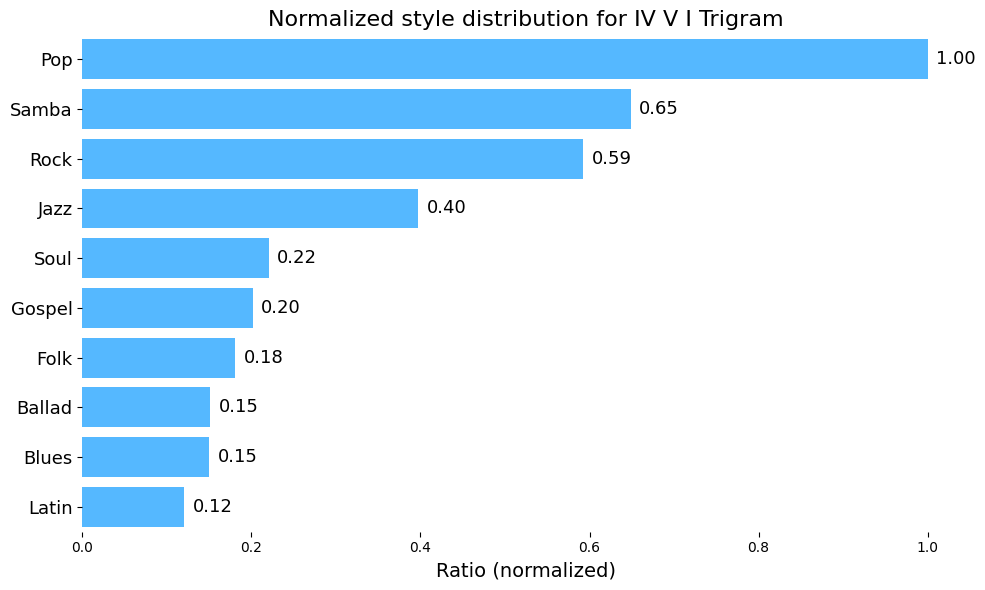

In [87]:
import matplotlib.pyplot as plt

find = ["IV", "V", "I"]

result = query_trigram_usage(find)

print(result)

styles_counts = result["functional_trigrams"]["styles"]
if not styles_counts:
    print("No styles to plot.")
else:
    labels, counts = zip(*styles_counts)
    counts = list(counts)
    max_count = max(counts)
    norm_counts = [c / max_count for c in counts]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels[::-1], norm_counts[::-1], color="#55b8ff", edgecolor="none")

    # Remove frame
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_ylim(-0.5, len(labels) - 0.5)

    # Add ratio labels
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.2f}", va='center', fontsize=13)

    ax.set_xlabel("Ratio (normalized)", fontsize=14)
    ax.set_title('Normalized style distribution for ' + ' '.join(find) + ' Trigram', fontsize=16)
    ax.tick_params(axis='y', labelsize=13)
    plt.tight_layout()
    plt.show()


In [38]:
import json

with open("/workspace/dataset/trigrams/trigram_dataset_lastfm.json", "r") as f:
    trigram_data = json.load(f)


In [39]:
import json
from collections import Counter

with open("/workspace/dataset/trigrams/trigram_dataset_lastfm.json") as f:
    trigram_data = json.load(f)

genre_counter = Counter()

for entry in trigram_data:
    # entry['genres'] is a list of [genre, weight]
    for genre, weight in entry.get('genres', []):
        genre_counter[genre] += weight

# Print top N genres
N = 30
print("Most common Dortmund genres in Last.fm trigrams:")
for genre, weight in genre_counter.most_common(N):
    print(f"{genre:15} {weight:.2f}")


Most common Dortmund genres in Last.fm trigrams:
rock            225970.24
electronic      97346.62
jazz            60663.54
pop             47060.91
alternative     44519.03
folkcountry     41263.07
raphiphop       39746.07
funksoulrnb     22239.99
blues           20481.06


In [40]:
from collections import defaultdict
import numpy as np

N = 30
# Include 'pop' and any other Dortmund genres you care about
chosen_styles = ['rock', 'electronic', 'jazz', 'pop', 'alternative', 'raphiphop', 'folkcountry', 'funksoulrnb', 'blues']

trigram_count = {}
trigram_genres = defaultdict(dict)

for entry in trigram_data:
    trigram = tuple(entry['function'])
    count = entry['count']
    trigram_count[trigram] = count
    # genres is a list of [genre, float sum]
    genre_counts = {k.lower(): v for k, v in entry['genres']}  # always lowercase for safety
    trigram_genres[trigram] = genre_counts

# Get top N trigrams by total count
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build data matrix (main genres + 'other')
data = []
totals = []
for trigram, _ in top_trigrams:
    genre_counts = trigram_genres[trigram]
    row = [genre_counts.get(style, 0) for style in chosen_styles]
    # "other" is sum of all dormund genres not in chosen_styles
    other_count = sum(v for k, v in genre_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending) (this actually does nothing since already sorted)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]


/tmp/ipykernel_1419756/3658402296.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_1419756/3658402296.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


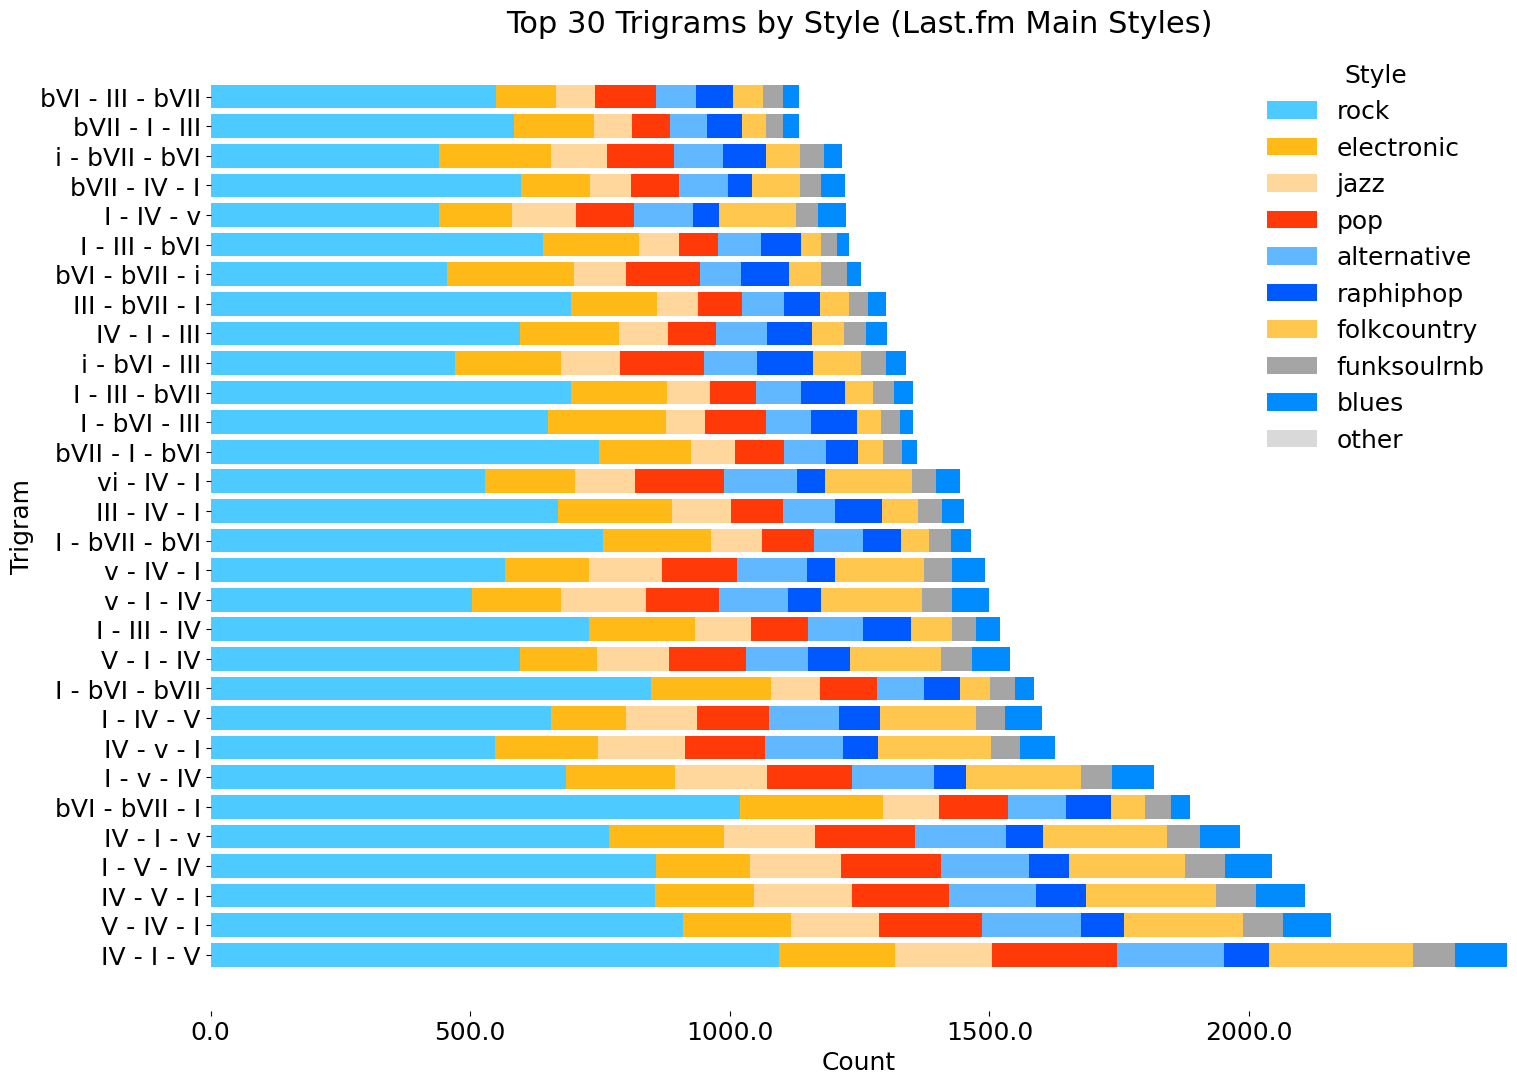

In [41]:
import matplotlib.pyplot as plt


custom_palette = {
    'rock': "#4dcaff",
    'electronic': "#ffba18",
    'jazz': "#ffd69c",
    'pop': "#ff3907",
    'alternative': "#61b8ff",
    'raphiphop': "#0059ff",
    'folkcountry': "#ffc74e",
    'funksoulrnb': "#a5a5a5",
    'blues': "#008cff",
    'other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['other']]

fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style (Last.fm Main Styles)', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()


In [42]:
import json

with open("/workspace/dataset/trigrams/trigram_dataset_lastfm.json") as f:
    trigram_data = json.load(f)

first_entry = trigram_data[0]

print("First trigram function:", first_entry["function"])
print("\nDortmund genres:")
for genre, weight in first_entry.get("genres", []):
    print(f"  {genre}: {weight:.2f}")

print("\nOriginal styles (from style.json 'original' tags):")
for style, count in first_entry.get("styles", []):
    print(f"  {style}: {count}")


First trigram function: ['IV', 'I', 'V']

Dortmund genres:
  rock: 1094.98
  folkcountry: 277.70
  pop: 240.97
  electronic: 223.81
  alternative: 206.30
  jazz: 185.35
  blues: 99.66
  raphiphop: 86.22
  funksoulrnb: 82.08

Original styles (from style.json 'original' tags):
  other: 10521
  rock: 5160
  pop: 3384
  metal: 1099
  punk: 772
  folk: 711
  indie: 667
  country: 493
  electronic: 420
  ambient: 326
  dance: 175
  soul: 99
  blues: 95
  reggae: 87
  jazz: 86
  experimental: 81
  hiphop: 70
  rnb: 54
  classical: 46
  funk: 21
  world: 17
  latin: 12


/tmp/ipykernel_1419756/3529088392.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_1419756/3529088392.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


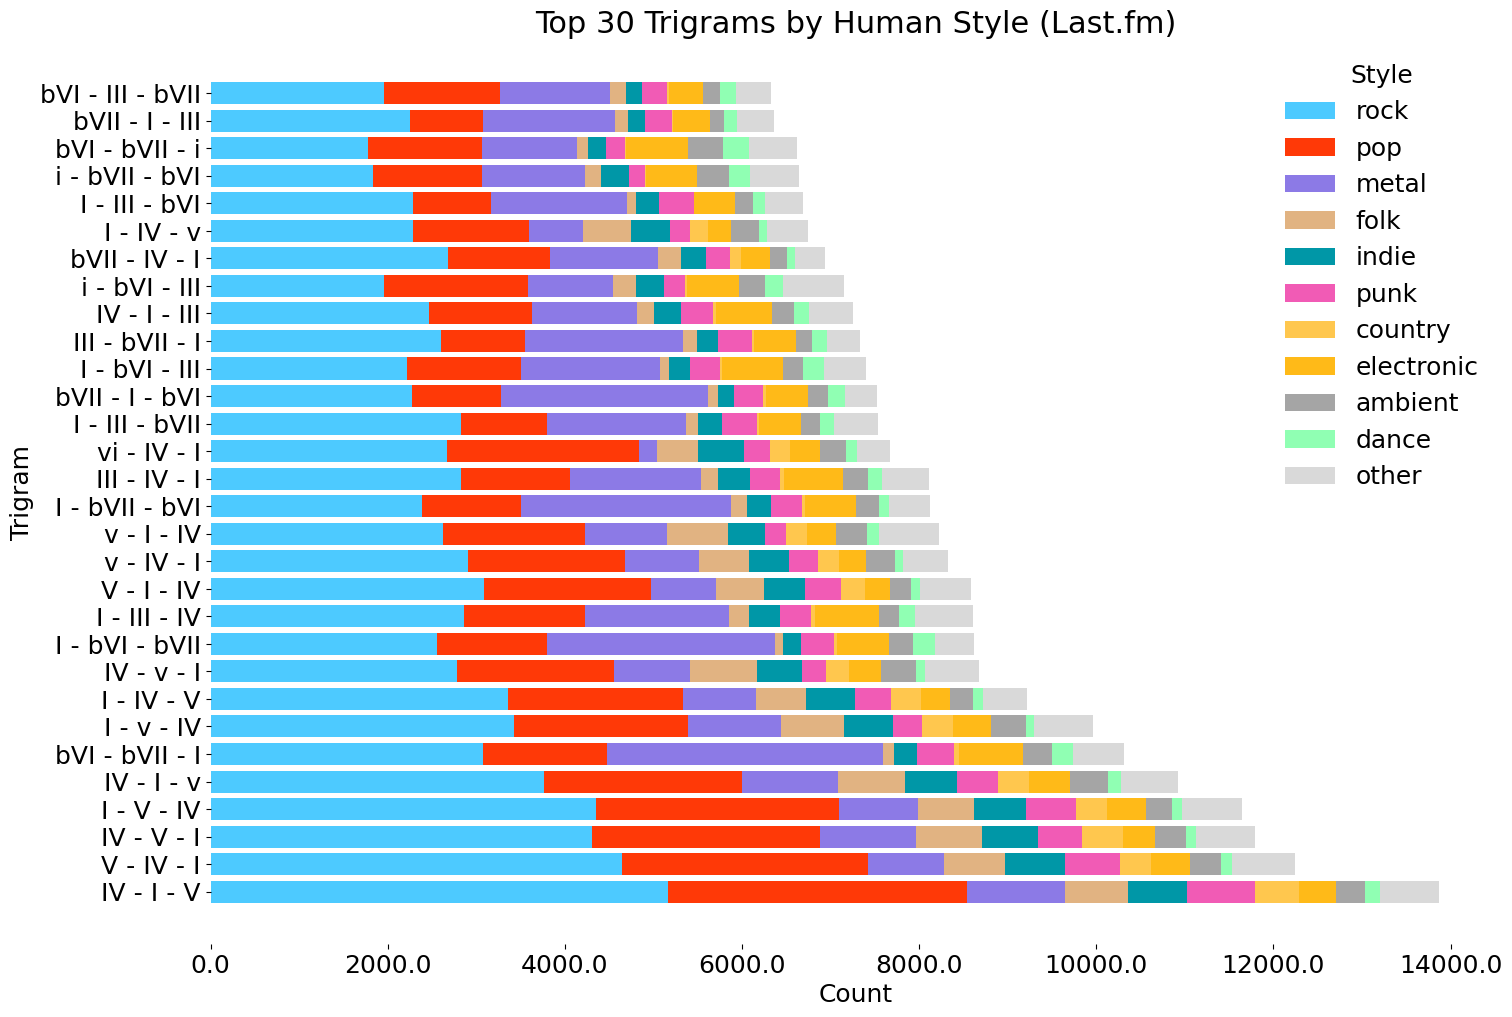

In [45]:
import json
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt

with open("/workspace/dataset/trigrams/trigram_dataset_lastfm.json") as f:
    trigram_data = json.load(f)

N = 30
# These match the most common human styles in your new dataset:
chosen_styles = [
    'rock', 'pop', 'metal', 'folk', 'indie', 'punk',
    'country', 'electronic', 'ambient', 'dance'
]

trigram_count = {}
trigram_styles = defaultdict(dict)

for entry in trigram_data:
    trigram = tuple(entry['function'])
    count = entry['count']
    trigram_count[trigram] = count
    # styles is a list of [genre, count]
    style_counts = {k.lower(): v for k, v in entry['styles']}
    trigram_styles[trigram] = style_counts

# Get top N trigrams by total count
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build data matrix (main genres + 'other')
data = []
totals = []
for trigram, _ in top_trigrams:
    style_counts = trigram_styles[trigram]
    row = [style_counts.get(style, 0) for style in chosen_styles]
    other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]

custom_palette = {
    'rock': "#4dcaff",
    'pop': "#ff3907",
    'metal': "#8c7ae6",
    'folk': "#e1b382",
    'indie': "#0097a7",
    'punk': "#f15bb5",
    'country': "#ffc74e",
    'electronic': "#ffba18",
    'ambient': "#a5a5a5",
    'dance': "#90ffb3",
    'other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['other']]

fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Human Style (Last.fm)', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)


In [72]:
# import json
# import re
# from collections import Counter, defaultdict

# def normalize_function_label(label):
#     match = re.match(r"([b#♭♯]*[IViv]+)", label)
#     return match.group(1) if match else label

# def normalize_trigram(function_trigram):
#     return tuple(normalize_function_label(x) for x in function_trigram)

# def normalize_style(style):
#     s = style
#     if s in ["Even 8th's", "Even 8's"]:
#         return 'Even 8ths'
#     if 'Swing' in s or 'Fusion' in s or 'Jazz' in s:
#         return 'Jazz'
#     if 'Blues' in s:
#         return 'Blues'
#     if 'Folk' in s:
#         return 'Folk'
#     if 'Bossa' in s:
#         return 'Bossa'
#     if 'Reggae' in s:
#         return 'Reggae'
#     if 'Samba' in s:
#         return 'Samba'
#     if 'Funk' in s:
#         return 'Funk'
#     if 'Pop' in s:
#         return 'Pop'
#     if 'Son' in s:
#         return 'Son'
#     if 'Rock' in s or s == 'Beatles':
#         return 'Rock'
#     if 'Soul' in s:
#         return 'Soul'
#     if 'Balad' in s:
#         return 'Balad'
#     if s == "R'n'B":
#         return "RnB"
#     if s == 'Afoxe':
#         return 'Afoxé'
#     if s in ['Worship', 'Traditional Gospel']:
#         return 'Gospel'
#     if s == 'Even 8ths':
#         return 'Pop'
#     return s

# # Load original data
# with open('/workspace/dataset/trigrams/trigram_dataset.json', 'r') as f:
#     data = json.load(f)

# # Aggregate trigrams
# trigram_count = Counter()
# trigram_styles = defaultdict(Counter)

# for entry in data:
#     func_trigram = normalize_trigram(entry['function'])
#     if len(set(func_trigram)) == 1:
#         continue  # Skip repetitive trigrams
#     count = entry['count']
#     for style in entry['styles']:
#         norm_style = normalize_style(style)
#         trigram_styles[func_trigram][norm_style] += count
#     trigram_count[func_trigram] += count

# # Build output (top N, or all if you prefer)
# N = 100  # or whatever number you want
# top_trigrams = trigram_count.most_common(N)

# output = []
# for trigram, count in top_trigrams:
#     style_list = [[style, weight] for style, weight in trigram_styles[trigram].most_common()]
#     output.append({
#         "function": list(trigram),
#         "count": count,
#         "styles": style_list
#     })

# # Save
# outpath = "/workspace/dataset/trigrams/functional_trigrams.json"
# with open(outpath, "w") as f:
#     json.dump(output, f, indent=2, ensure_ascii=False)

# print(f"Saved {len(output)} trigrams to {outpath}")
